# Section 1 - Dataset Description and Experimental Design

In [343]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split

In [344]:
# Set random seed for reproducibility
import numpy as np
import random

# Define a random seed for reproducibility
SEED = 42

# Set the random seed for both numpy and random
np.random.seed(SEED)
random.seed(SEED)

## 1.1 Dataset Characteristics

In [345]:
#Loading in Dataset
df = pd.read_csv('../datasets/SMI_Train_4214293.csv')

# Display the shape of the dataset
df.shape

(8000, 171)

In [346]:
# Display a summary of the dataframe to verify column data types (ensuring sensors are float64) and check non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Columns: 171 entries, class to Sensor_170
dtypes: int64(1), str(170)
memory usage: 10.4 MB


In [347]:
# Display the first few rows of the dataframe
df.head()

,class,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,Sensor_007,Sensor_008,Sensor_009,...,Sensor_161,Sensor_162,Sensor_163,Sensor_164,Sensor_165,Sensor_166,Sensor_167,Sensor_168,Sensor_169,Sensor_170
0,neg,10,0,8,8,0,0,0,0,0,...,56,34,70,70,2,0,0,0,0,0
1,neg,1954,na,60,60,0,0,0,0,0,...,8628,4788,12536,63870,28,0,0,0,0,0
2,neg,29304,na,594,474,0,0,0,0,0,...,224856,101102,217024,253494,199228,117920,160068,10444,0,0
3,neg,33736,na,112,90,0,0,0,0,0,...,63708,39832,91816,183518,889270,174658,554,178,0,0
4,neg,24,na,62,42,0,0,0,0,0,...,344,46,8,0,0,0,0,0,0,0


In [348]:
# Calculate and print the total number of observations in the dataset
total_obs = len(df)
print(f"Total observations: {total_obs}")

# Calculate Class Imbalance
class_counts = df['class'].value_counts()
pos_count = class_counts.get('pos', 0)
neg_count = class_counts.get('neg', 0)
pos_pct = (pos_count / total_obs) * 100
neg_pct = (neg_count / total_obs) * 100

print(f"Positive class (pos): {pos_count} instances ({pos_pct:.2f}%)")
print(f"Negative class (neg): {neg_count} instances ({neg_pct:.2f}%)")

Total observations: 8000
Positive class (pos): 133 instances (1.66%)
Negative class (neg): 7867 instances (98.34%)


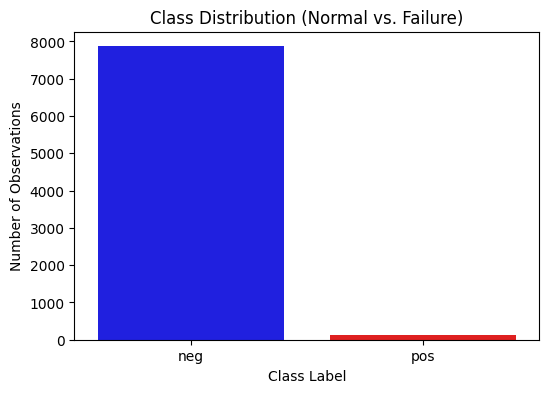

In [349]:
# Plot Class Imbalance (Save this plot for your report)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', palette={'neg': 'blue', 'pos': 'red'})
plt.title('Class Distribution (Normal vs. Failure)')
plt.ylabel('Number of Observations')
plt.xlabel('Class Label')
plt.show()

## 1.2 Data Quality and Missingness

In [350]:
# Replace 'na' strings with actual numpy NaN values
df.replace('na', np.nan, inplace=True)

,class,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,Sensor_007,Sensor_008,Sensor_009,...,Sensor_161,Sensor_162,Sensor_163,Sensor_164,Sensor_165,Sensor_166,Sensor_167,Sensor_168,Sensor_169,Sensor_170
0,neg,10,0,8,8,0,0,0,0,0,...,56,34,70,70,2,0,0,0,0,0
1,neg,1954,NaN,60,60,0,0,0,0,0,...,8628,4788,12536,63870,28,0,0,0,0,0
2,neg,29304,NaN,594,474,0,0,0,0,0,...,224856,101102,217024,253494,199228,117920,160068,10444,0,0
3,neg,33736,NaN,112,90,0,0,0,0,0,...,63708,39832,91816,183518,889270,174658,554,178,0,0
4,neg,24,NaN,62,42,0,0,0,0,0,...,344,46,8,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,neg,1730,NaN,2130706432,20,0,0,0,0,0,...,6704,4706,30222,39864,140,0,0,0,0,0
7996,neg,28,NaN,42,36,0,0,0,0,0,...,594,98,28,0,0,0,0,0,0,0
7997,neg,58206,NaN,2130706432,218,0,0,0,0,0,...,311024,147776,305886,242466,234308,231342,942242,660,0,0
7998,neg,14,NaN,30,NaN,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [351]:
# Convert all sensor columns (object or integer) to float
sensor_cols = [col for col in df.columns if 'Sensor' in col]
df[sensor_cols] = df[sensor_cols].apply(pd.to_numeric, errors='coerce').astype(float)

In [352]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Columns: 171 entries, class to Sensor_170
dtypes: float64(170), str(1)
memory usage: 10.4 MB


In [353]:
# Calculate overall missingness
total_cells = df[sensor_cols].size
missing_cells = df[sensor_cols].isna().sum().sum()
overall_missing_pct = (missing_cells / total_cells) * 100
print(f"Overall dataset missingness: {overall_missing_pct:.2f}%")

Overall dataset missingness: 8.29%


In [354]:
# Calculate missingness per feature
missing_per_feature = df[sensor_cols].isna().sum()
features_with_missing = (missing_per_feature > 0).sum()

print(f"Number of features with missing values: {features_with_missing}")

Number of features with missing values: 169


In [355]:
# Find the feature with the highest missingness
highest_missing_col = missing_per_feature.idxmax()
highest_missing_count = missing_per_feature.max()
highest_missing_pct = (highest_missing_count / total_obs) * 100
print(f"Feature with the highest missingness: {highest_missing_col} ({highest_missing_pct:.2f}%)")

Feature with the highest missingness: Sensor_079 (82.11%)


In [356]:
# Class masks for conditional analysis
pos_mask = df['class'] == 'pos'
neg_mask = df['class'] == 'neg'

# Per-feature missing rate split by class
miss_pos = df[sensor_cols][pos_mask].isnull().mean() * 100
miss_neg = df[sensor_cols][neg_mask].isnull().mean() * 100

# Rank features by size of the pos-neg missingness gap
miss_diff = (miss_pos - miss_neg).sort_values(ascending=False)

print(f'Missing rate — Pos: {miss_pos.mean():.2f}%  |  Neg: {miss_neg.mean():.2f}%')

Missing rate — Pos: 18.33%  |  Neg: 8.13%


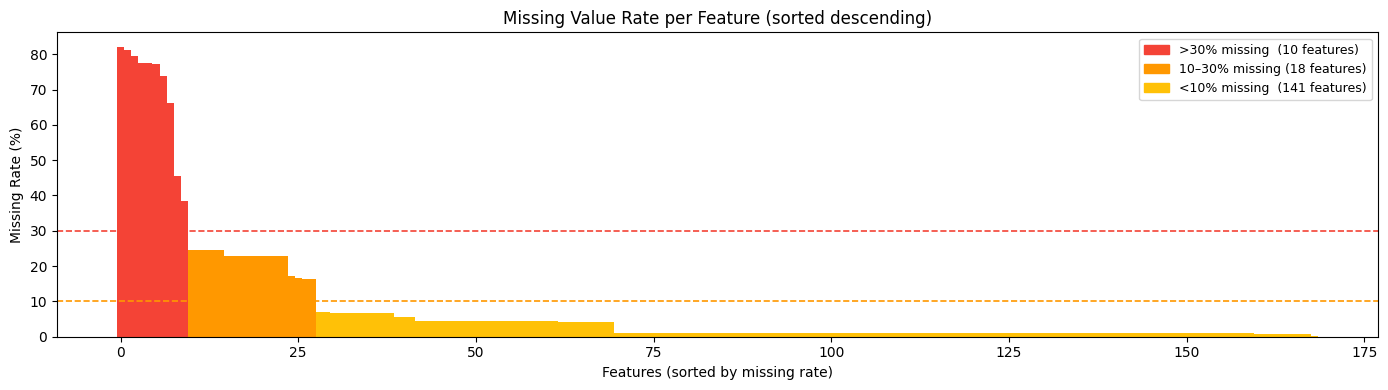

In [357]:
# Per-feature missing rate (%)
miss_pct = (missing_per_feature / total_obs * 100).round(2)

# Colour-code bars by missingness severity: red >30%, orange 10-30%, yellow <10%
feat_miss = miss_pct[miss_pct > 0].sort_values(ascending=False)
colors = ['#F44336' if v > 30 else '#FF9800' if v > 10 else '#FFC107' for v in feat_miss.values]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(feat_miss)), feat_miss.values, color=colors, width=1.0)
ax.axhline(10, color='#FF9800', linestyle='--', linewidth=1.2)
ax.axhline(30, color='#F44336', linestyle='--', linewidth=1.2)
ax.legend(handles=[
    mpatches.Patch(color='#F44336', label=f">30% missing  ({(miss_pct > 30).sum()} features)"),
    mpatches.Patch(color='#FF9800', label=f"10–30% missing ({((miss_pct > 10) & (miss_pct <= 30)).sum()} features)"),
    mpatches.Patch(color='#FFC107', label=f"<10% missing  ({((miss_pct > 0) & (miss_pct <= 10)).sum()} features)"),
], fontsize=9)
ax.set_title('Missing Value Rate per Feature (sorted descending)')
ax.set_xlabel('Features (sorted by missing rate)')
ax.set_ylabel('Missing Rate (%)')
plt.tight_layout()
plt.show()

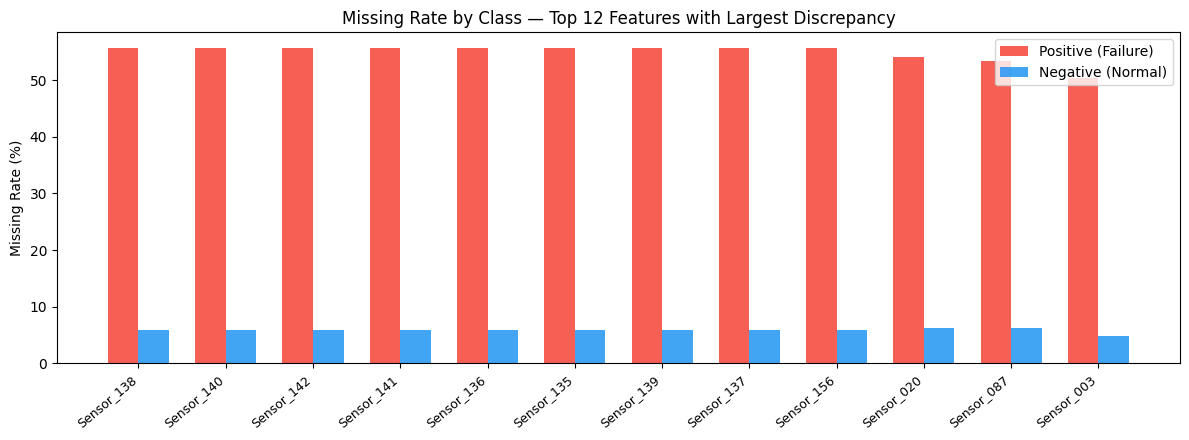

In [358]:
# Select the 12 features where the pos-neg missingness gap is largest
top_diff_feats = miss_diff.nlargest(12).index
x, w = np.arange(len(top_diff_feats)), 0.35

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - w/2, miss_pos[top_diff_feats].values, w, label='Positive (Failure)', color='#F44336', alpha=0.85)
ax.bar(x + w/2, miss_neg[top_diff_feats].values, w, label='Negative (Normal)',  color='#2196F3', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_diff_feats, rotation=40, ha='right', fontsize=9)
ax.set_title('Missing Rate by Class — Top 12 Features with Largest Discrepancy')
ax.set_ylabel('Missing Rate (%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 1.3 Feature Relevance & Correlation

In [359]:
# Class-conditional mean difference — ranks features by discriminative power
mean_diff = (df[sensor_cols][pos_mask].mean() - df[sensor_cols][neg_mask].mean()).abs()

# Spearman correlation — robust to the extreme skew present in sensor data
print('Computing Spearman correlation matrix...')
corr_matrix = df[sensor_cols].corr(method='spearman')

# Upper triangle only — avoids double-counting pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
print(f'Feature pairs |corr| > 0.95 : {(upper.abs() > 0.95).sum().sum()}')
print(f'Feature pairs |corr| > 0.80 : {(upper.abs() > 0.80).sum().sum()}')

Computing Spearman correlation matrix...
Feature pairs |corr| > 0.95 : 171
Feature pairs |corr| > 0.80 : 1855


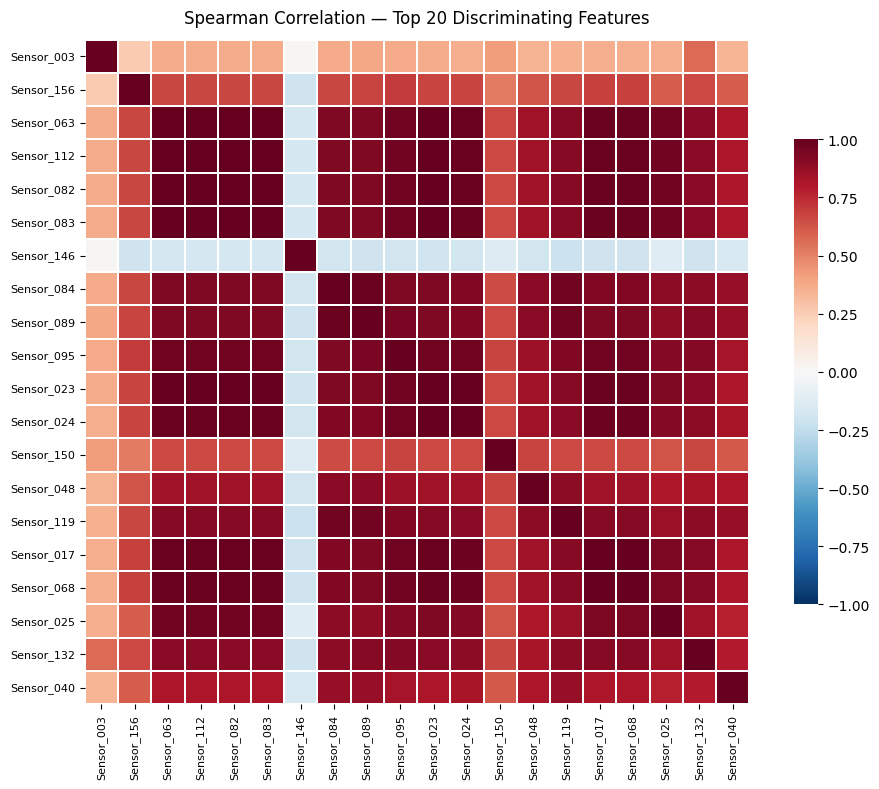

In [360]:
# Restrict heatmap to the 20 most discriminating features to keep it readable
top20_feats = mean_diff.nlargest(20).index.tolist()
corr_sub    = corr_matrix.loc[top20_feats, top20_feats]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_sub, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7})
ax.tick_params(labelsize=8)
ax.set_title('Spearman Correlation — Top 20 Discriminating Features', pad=12)
plt.tight_layout()
plt.show()

## 1.4 Experimental Design

In [361]:
X = df[sensor_cols]
y = df['class'].map({'neg':0, 'pos':1})

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("\n--- Experimental Split ---")
print(f"Training set size: {len(X_train)} observations")
print(f"Validation set size: {len(X_val)} observations")


--- Experimental Split ---
Training set size: 6400 observations
Validation set size: 1600 observations


## 1.5 Summary

The exploratory analysis revealed several key challenges in the dataset:

- **Severe class imbalance** (only 1.66% of observations correspond to failure events)
- **Approximately 8% missing sensor data** across 169 of 170 features
- **High dimensionality**, with 170 sensor features
- **Evidence of informative missingness** — the failure class exhibited 18.33% missing data versus 8.13% for the normal class, suggesting that the absence of a sensor reading itself carries predictive value
- **Strong correlations between certain sensors** — 171 feature pairs with |ρ| > 0.95 and 1,855 pairs with |ρ| > 0.80, indicating substantial multicollinearity

To address these challenges, preprocessing techniques such as missing value imputation with missingness indicator flags, feature scaling, variance-based feature filtering, and pipeline-based modelling will be implemented in Section 2.

# Section 2 - Preprocessing and Model Development

In this section, appropriate preprocessing techniques will be applied to prepare the dataset for machine learning modelling. This will include handling missing values, mitigating the effects of class imbalance, reducing dimensionality, and applying feature engineering where necessary. In addition, models will be developed based on the student ID 4214293, following the coursework requirements. These steps aim to improve model performance, stability, and the overall reliability of the predictive maintenance system.

In [362]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, precision_score,
    average_precision_score
)

print("Section 2 libraries imported successfully.")

Section 2 libraries imported successfully.


## 2.1 Preprocessing Pipeline

The preprocessing pipeline is constructed using scikit-learn's `Pipeline` class to ensure all transformations are fitted exclusively on training data and subsequently applied to validation and test data, thereby preventing data leakage.

**Design decisions justified by EDA findings:**

- **Median imputation** (`SimpleImputer(strategy='median')`): Median is robust to the heavy right-skew and extreme outliers observed across sensor distributions. Applied with `add_indicator=True` to generate binary missingness indicator columns, preserving the informative missingness signal identified in EDA (failure class: 18.33% missing vs. normal class: 8.13%).
- **Variance threshold filtering** (`VarianceThreshold(threshold=0.0)`): Removes zero-variance features that contribute no discriminative information, reducing redundancy after indicator columns are appended.
- **Log1p transformation** *(MLP pipeline only)*: Sensor distributions exhibit strong right-skew with values spanning multiple orders of magnitude. Log-compression normalises these distributions prior to scaling, improving gradient stability during MLP training.
- **Standard scaling** *(MLP pipeline only)*: MLP is sensitive to feature magnitude; zero-mean unit-variance scaling ensures equal contribution from all features and stable gradient descent. Tree-based models are invariant to monotone transforms and do not require scaling.
- **Class imbalance handling**: The 60:1 class ratio (98.34% vs. 1.66%) is addressed by computing inverse-frequency sample weights (`compute_sample_weight('balanced')`) passed at fit time for GBM and MLP. Random Forest uses the native `class_weight='balanced'` parameter.

In [363]:
# --- Feature Engineering Helper ---
def log1p_clip(X):
    """Log1p transform with negative clipping — safe for right-skewed sensor data."""
    return np.log1p(np.clip(X, 0, None))

# --- Sample weights for class-imbalance handling (GBM and MLP) ---
# Equivalent to class_weight='balanced': inverse-frequency weighting
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# --- Pipeline steps for tree-based models (GBM, Random Forest) ---
# Tree models are invariant to monotone transforms; imputation + var filter sufficient
tree_pipeline_steps = [
    ('imputer',    SimpleImputer(strategy='median', add_indicator=True)),
    ('var_filter', VarianceThreshold(threshold=0.0)),
]

# --- Pipeline steps for MLP ---
# MLP requires normalised inputs; log1p reduces right-skew, StandardScaler normalises
mlp_pipeline_steps = [
    ('imputer',       SimpleImputer(strategy='median', add_indicator=True)),
    ('log_transform', FunctionTransformer(log1p_clip, validate=False)),
    ('var_filter',    VarianceThreshold(threshold=0.0)),
    ('scaler',        StandardScaler()),
]

# Verify output shapes (fit on training data only — no leakage)
_tree_out = Pipeline(tree_pipeline_steps).fit_transform(X_train)
_mlp_out  = Pipeline(mlp_pipeline_steps).fit_transform(X_train)
print(f"Tree preprocessor: {X_train.shape[1]} raw features → {_tree_out.shape[1]} "
      f"(+{_tree_out.shape[1] - X_train.shape[1]} missingness indicators, after var filter)")
print(f"MLP  preprocessor: {X_train.shape[1]} raw features → {_mlp_out.shape[1]}")
del _tree_out, _mlp_out

Tree preprocessor: 170 raw features → 338 (+168 missingness indicators, after var filter)
MLP  preprocessor: 170 raw features → 338


## 2.2 Preprocessing Verification

The cells below verify the preprocessing output and visualise key structural properties of the data — sparsity and feature distributions — to confirm the pipeline is operating as expected before model training.

In [364]:
# --- Preprocessing output verification ---
# Fit tree and MLP preprocessors on training data only, then check output dimensions

from sklearn.pipeline import Pipeline

_tree_pre = Pipeline(tree_pipeline_steps)
_mlp_pre  = Pipeline(mlp_pipeline_steps)

X_train_tree = _tree_pre.fit_transform(X_train)
X_train_mlp  = _mlp_pre.fit_transform(X_train)

n_raw         = X_train.shape[1]
n_indicators  = X_train_tree.shape[1] - n_raw
n_tree_feats  = X_train_tree.shape[1]
n_mlp_feats   = X_train_mlp.shape[1]

print("=" * 55)
print(f"{'Stage':<35} {'Features':>8}")
print("=" * 55)
print(f"{'Raw sensor features':<35} {n_raw:>8}")
print(f"{'Missingness indicators added':<35} {n_indicators:>8}")
print(f"{'After impute + var-filter (tree)':<35} {n_tree_feats:>8}")
print(f"{'After impute + log1p + scale (MLP)':<35} {n_mlp_feats:>8}")
print("=" * 55)
print(f"\nTraining rows: {X_train.shape[0]}  |  Validation rows: {X_val.shape[0]}")

# Sanity check: positive class ratio preserved after split
print(f"\nClass balance — Train pos: {y_train.mean()*100:.2f}%  "
      f"|  Val pos: {y_val.mean()*100:.2f}%")

del X_train_tree, X_train_mlp, _tree_pre, _mlp_pre

Stage                               Features
Raw sensor features                      170
Missingness indicators added             168
After impute + var-filter (tree)         338
After impute + log1p + scale (MLP)       338

Training rows: 6400  |  Validation rows: 1600

Class balance — Train pos: 1.66%  |  Val pos: 1.69%


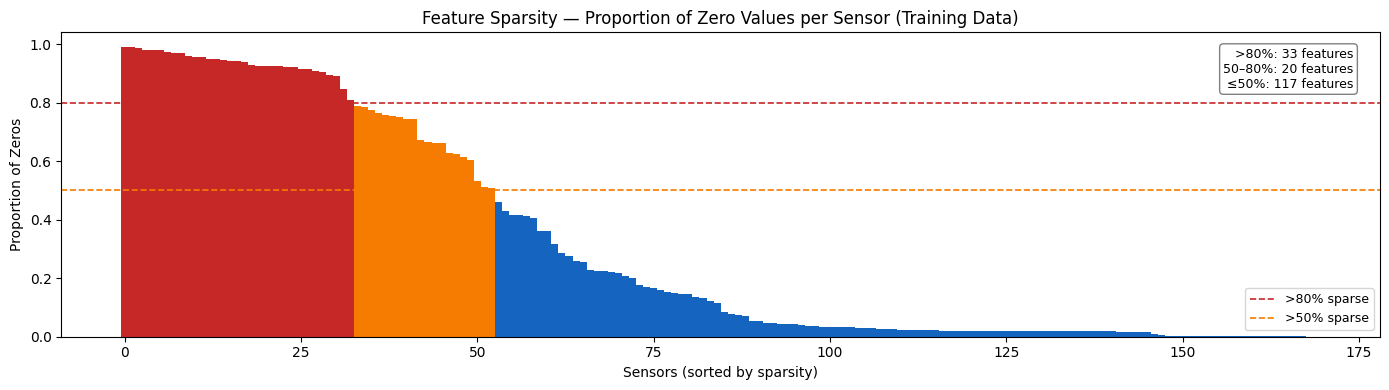

Sensors with >80% zero values: 33
Sensors with 50–80% zero values: 20


In [365]:
# Figure 4 — Feature Sparsity
# Proportion of zeros per feature (many sensors read 0 during normal operation)
# Fitted on training data only

sparsity = (X_train == 0).mean().sort_values(ascending=False)

# Colour bars: dark red >80% sparse, orange 50-80%, blue <50%
colors_sp = ['#C62828' if v > 0.80 else '#F57C00' if v > 0.50 else '#1565C0'
             for v in sparsity.values]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(sparsity)), sparsity.values, color=colors_sp, width=1.0)
ax.axhline(0.80, color='#C62828', linestyle='--', linewidth=1.2, label='>80% sparse')
ax.axhline(0.50, color='#F57C00', linestyle='--', linewidth=1.2, label='>50% sparse')
ax.set_title('Feature Sparsity — Proportion of Zero Values per Sensor (Training Data)')
ax.set_xlabel('Sensors (sorted by sparsity)')
ax.set_ylabel('Proportion of Zeros')
ax.legend(fontsize=9)
n_very_sparse  = (sparsity > 0.80).sum()
n_mod_sparse   = ((sparsity > 0.50) & (sparsity <= 0.80)).sum()
n_dense        = (sparsity <= 0.50).sum()
ax.text(0.98, 0.95,
        f">80%: {n_very_sparse} features\n50–80%: {n_mod_sparse} features\n≤50%: {n_dense} features",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey'))
plt.tight_layout()
plt.savefig('fig4_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sensors with >80% zero values: {n_very_sparse}")
print(f"Sensors with 50–80% zero values: {n_mod_sparse}")

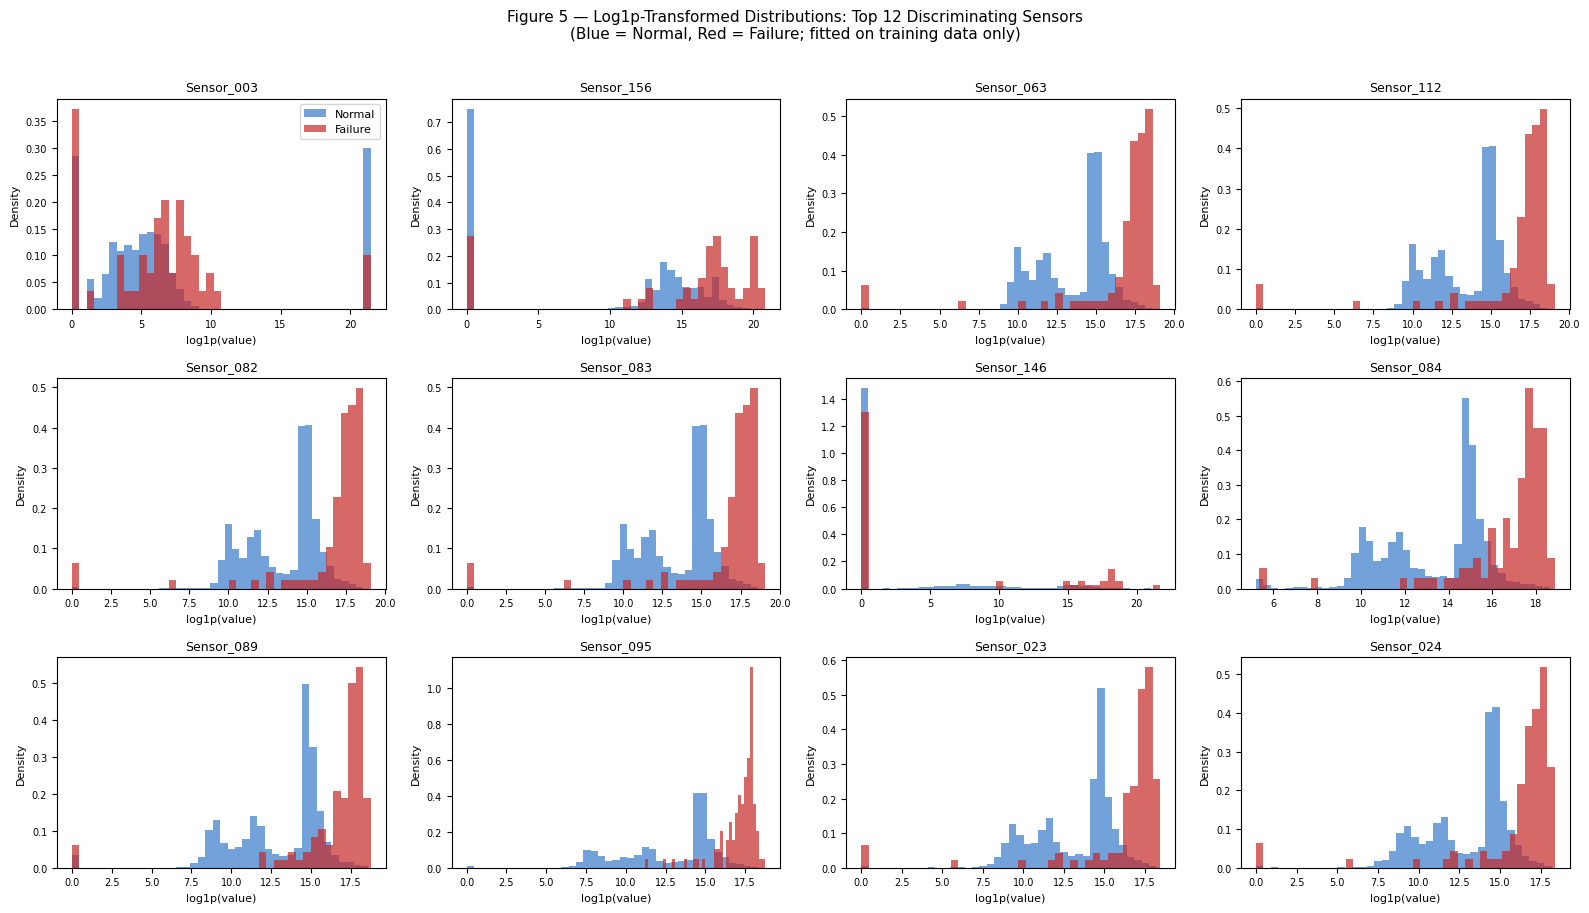

In [366]:
# Figure 5 — Feature Distributions (Top 12 most discriminating sensors)
# Shows raw vs log1p distribution split by class label
# Confirms right-skew motivating the log1p transform in the MLP pipeline

top12 = mean_diff.nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top12):
    ax = axes[i]
    neg_vals = X_train.loc[y_train == 0, feat].dropna()
    pos_vals = X_train.loc[y_train == 1, feat].dropna()
    # Log1p transform for display (mirrors MLP pipeline step)
    ax.hist(np.log1p(neg_vals), bins=40, alpha=0.6, color='#1565C0', label='Normal', density=True)
    ax.hist(np.log1p(pos_vals), bins=40, alpha=0.7, color='#C62828', label='Failure', density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('log1p(value)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Figure 5 — Log1p-Transformed Distributions: Top 12 Discriminating Sensors\n'
             '(Blue = Normal, Red = Failure; fitted on training data only)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('fig5_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Model Development and Hyperparameter Tuning

Three models are assigned for student ID 4214293:

| # | Model | Key Characteristics |
|---|-------|---------------------|
| 1 | **Gradient Boosting Classifier** | Sequential ensemble of shallow trees; robust to mixed-scale features; handles imbalance via sample weights |
| 2 | **Multi-Layer Perceptron Classifier** | Feed-forward neural network; sensitive to feature scale (log1p + StandardScaler applied); handles imbalance via sample weights |
| 3 | **Random Forest Classifier** | Parallel ensemble of trees; inherently robust to outliers; supports `class_weight='balanced'` directly |

**Validation strategy**: Stratified 5-fold cross-validation (`StratifiedKFold`) preserves the class ratio (~1.66% positive) in each fold, ensuring reliable performance estimates under severe imbalance.

**Tuning objective**: `f1` score on the positive (failure) class is used as the primary scoring metric, reflecting the cost-asymmetric operational context where missing a failure (FN cost = 500) is substantially more costly than a false alarm (FP cost = 10).

**Search method**: `RandomizedSearchCV` with `n_iter=20` provides efficient exploration of the hyperparameter space without exhaustive grid search.

In [367]:
# ─────────────────────────────────────────────
# Model 1: Gradient Boosting Classifier
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gbm_pipeline = Pipeline(tree_pipeline_steps + [
    ('classifier', GradientBoostingClassifier(random_state=SEED))
])

gbm_param_dist = {
    'classifier__n_estimators':    [100, 200, 300, 400],
    'classifier__max_depth':       [2, 3, 4, 5],
    'classifier__learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample':       [0.6, 0.7, 0.8, 1.0],
    'classifier__min_samples_leaf':[5, 10, 20, 30],
}

gbm_search = RandomizedSearchCV(
    gbm_pipeline,
    gbm_param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
    refit=True
)

gbm_search.fit(
    X_train, y_train,
    classifier__sample_weight=sample_weights_train
)

print("\n=== Gradient Boosting Classifier ===")
print(f"Best CV F1 (pos class): {gbm_search.best_score_:.4f}")
print(f"Best params: {gbm_search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Gradient Boosting Classifier ===
Best CV F1 (pos class): 0.6891
Best params: {'classifier__subsample': 0.7, 'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 20, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05}


In [368]:
# ─────────────────────────────────────────────
# Model 2: Multi-Layer Perceptron Classifier
# ─────────────────────────────────────────────
mlp_pipeline = Pipeline(mlp_pipeline_steps + [
    ('classifier', MLPClassifier(
        random_state=SEED,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

mlp_param_dist = {
    'classifier__hidden_layer_sizes': [(100,), (100, 50), (200, 100), (100, 100), (150, 75)],
    'classifier__alpha':              [0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate_init': [0.0001, 0.001, 0.01],
    'classifier__activation':         ['relu', 'tanh'],
    'classifier__solver':             ['adam'],
}

mlp_search = RandomizedSearchCV(
    mlp_pipeline,
    mlp_param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
    refit=True
)

mlp_search.fit(
    X_train, y_train,
    classifier__sample_weight=sample_weights_train
)

print("\n=== Multi-Layer Perceptron Classifier ===")
print(f"Best CV F1 (pos class): {mlp_search.best_score_:.4f}")
print(f"Best params: {mlp_search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Multi-Layer Perceptron Classifier ===
Best CV F1 (pos class): 0.5107
Best params: {'classifier__solver': 'adam', 'classifier__learning_rate_init': 0.001, 'classifier__hidden_layer_sizes': (100, 100), 'classifier__alpha': 0.1, 'classifier__activation': 'relu'}


In [369]:
# ─────────────────────────────────────────────
# Model 3: Random Forest Classifier
# ─────────────────────────────────────────────
rf_pipeline = Pipeline(tree_pipeline_steps + [
    ('classifier', RandomForestClassifier(
        random_state=SEED,
        class_weight='balanced',  # natively supported — no sample_weight needed
        n_jobs=-1
    ))
])

rf_param_dist = {
    'classifier__n_estimators':    [100, 200, 300, 400],
    'classifier__max_depth':       [None, 10, 20, 30],
    'classifier__min_samples_leaf':[1, 5, 10, 20],
    'classifier__max_features':    ['sqrt', 'log2', 0.3],
    'classifier__bootstrap':       [True, False],
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
    refit=True
)

rf_search.fit(X_train, y_train)

print("\n=== Random Forest Classifier ===")
print(f"Best CV F1 (pos class): {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Random Forest Classifier ===
Best CV F1 (pos class): 0.5815
Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'log2', 'classifier__max_depth': 10, 'classifier__bootstrap': False}


In [370]:
# ─────────────────────────────────────────────
# Tuning Summary — Cross-Validation F1 Comparison
# ─────────────────────────────────────────────
tuning_results = {
    'Gradient Boosting':      gbm_search.best_score_,
    'Multi-Layer Perceptron': mlp_search.best_score_,
    'Random Forest':          rf_search.best_score_,
}

print("=" * 52)
print(f"{'Model':<32} {'Best CV F1':>10}")
print("=" * 52)
for name, score in sorted(tuning_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<32} {score:>10.4f}")
print("=" * 52)
print("\nNote: CV F1 is computed on the positive (failure) class")
print("using 5-fold stratified cross-validation on training data")
print("only. These results inform but do not constitute final")
print("benchmarking, which is performed on the held-out validation set.")

Model                            Best CV F1
Gradient Boosting                    0.6891
Random Forest                        0.5815
Multi-Layer Perceptron               0.5107

Note: CV F1 is computed on the positive (failure) class
using 5-fold stratified cross-validation on training data
only. These results inform but do not constitute final
benchmarking, which is performed on the held-out validation set.
